# 03 — Meta-Labeling & Meta-Model

**Purpose:** Implement the Lopez de Prado Meta-Labeling framework.

**Architecture:**
- **Triple-Barrier Method**: Label trades as success (1) or failure (0) using
  dynamic volatility-based barriers
- **Meta-Model (Critic)**: Random Forest that learns WHEN the Alpha model is
  likely to be correct. Outputs `P(Success)` — probability the trade is profitable
- This probability is used for bet-sizing in the HRP portfolio (Notebook 05)

**Key insight:** The Alpha model provides direction. The Meta-model filters noise.
Only take trades where P(Success) > threshold.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
WD = Path('.')

# ── Parameters ────────────────────────────────────────────────────────────────
VOL_WINDOW          = 21      # rolling window for daily volatility estimate
UPPER_MULTIPLIER    = 1.5     # take-profit: +1.5σ
LOWER_MULTIPLIER    = 1.0     # stop-loss:   -1.0σ
VERTICAL_BARRIER    = 5       # time limit: 5 trading days
PSUCCESS_THRESHOLD  = 0.55    # only trade when P(Success) > this
META_TRAIN_FRAC     = 0.7     # temporal train/test split for meta-model

print('✓ Imports loaded')

✓ Imports loaded


## 1 — Load Data & Alpha Predictions

In [2]:
# Load feature panel (for raw returns + features needed for meta-model)
panel = pd.read_parquet(WD / 'features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel = panel.sort_values(['ticker', 'date']).reset_index(drop=True)

# Load OOS predictions from Alpha model
oos_preds = pd.read_parquet(WD / 'oos_predictions.parquet')
oos_preds['date'] = pd.to_datetime(oos_preds['date'])

with open(WD / 'feature_meta.json', 'r') as f:
    meta = json.load(f)

SELECTED_FEATS = meta['selected_features']

print(f'Panel: {len(panel):,} rows  |  {panel["ticker"].nunique()} tickers')
print(f'OOS predictions: {len(oos_preds):,} rows')
print(f'OOS columns: {oos_preds.columns.tolist()}')

Panel: 1,512,735 rows  |  499 tickers
OOS predictions: 606,878 rows
OOS columns: ['date', 'ticker', 'fwd_ret_5d', 'target_cs_rank', 'pred_lgb_momentum', 'pred_lgb_volatility', 'pred_lgb_technical', 'pred_lgb_combined', 'pred_ensemble', 'pred_decile']


## 2 — Triple-Barrier Labeling

In [3]:
# ── Triple-Barrier Method ─────────────────────────────────────────────────────
#
# For each (date, ticker) where the Alpha model fires a signal:
#   1. Estimate daily volatility σ (rolling 21-day std of log returns)
#   2. Set barriers:
#      - Upper  =  +UPPER_MULTIPLIER × σ × √VERTICAL_BARRIER
#      - Lower  =  -LOWER_MULTIPLIER × σ × √VERTICAL_BARRIER
#      - Vertical = t + VERTICAL_BARRIER days
#   3. Simulate the cumulative return forward
#   4. Label: 1 if upper barrier hit first (or cum_ret > 0 at vertical), else 0

def triple_barrier_label(
    ticker_df:        pd.DataFrame,
    upper_mult:       float = UPPER_MULTIPLIER,
    lower_mult:       float = LOWER_MULTIPLIER,
    vertical_barrier: int   = VERTICAL_BARRIER,
    vol_window:       int   = VOL_WINDOW
) -> pd.DataFrame:
    """
    Compute triple-barrier label for a single ticker.
    Input df must be sorted by date and contain 'log_ret'.
    Returns df with columns: 'tb_label', 'tb_ret', 'vol_sigma'
    """
    df = ticker_df.copy().reset_index(drop=True)
    n  = len(df)

    # Daily volatility
    df['vol_sigma'] = df['log_ret'].rolling(vol_window, min_periods=vol_window // 2).std()

    labels      = np.full(n, np.nan)
    barrier_ret = np.full(n, np.nan)

    log_rets = df['log_ret'].values
    sigmas   = df['vol_sigma'].values

    for i in range(n - vertical_barrier):
        sigma = sigmas[i]
        if np.isnan(sigma) or sigma == 0:
            continue

        upper = upper_mult * sigma * np.sqrt(vertical_barrier)
        lower = -lower_mult * sigma * np.sqrt(vertical_barrier)

        cum_ret = 0.0
        outcome = 0  # default: failure (time expiry with negative return)

        for j in range(1, vertical_barrier + 1):
            cum_ret += log_rets[i + j]
            if cum_ret >= upper:
                outcome = 1  # profit target hit
                break
            if cum_ret <= lower:
                outcome = 0  # stop-loss hit
                break
        else:
            # Vertical barrier hit: label by sign of cumulative return
            outcome = 1 if cum_ret > 0 else 0

        labels[i]      = outcome
        barrier_ret[i] = cum_ret

    df['tb_label'] = labels
    df['tb_ret']   = barrier_ret
    return df


print('Triple-Barrier function defined ✓')

Triple-Barrier function defined ✓


In [4]:
%%time
# Apply triple-barrier labeling to all tickers
print('Computing triple-barrier labels (vectorized per ticker)...')

# Only need date, ticker, log_ret per ticker
tb_input = panel[['date', 'ticker', 'log_ret']].copy()

labeled_parts = []
for ticker, grp in tb_input.groupby('ticker'):
    grp_sorted = grp.sort_values('date')
    labeled    = triple_barrier_label(grp_sorted)
    labeled_parts.append(labeled[['date', 'ticker', 'tb_label', 'tb_ret', 'vol_sigma']])

tb_labels = pd.concat(labeled_parts, ignore_index=True)
tb_labels = tb_labels.dropna(subset=['tb_label'])

label_rate  = tb_labels['tb_label'].value_counts(normalize=True)
print(f'\nLabels computed: {len(tb_labels):,} rows')
print(f'Success (1): {label_rate.get(1.0, 0):.1%}  |  Failure (0): {label_rate.get(0.0, 0):.1%}')

Computing triple-barrier labels (vectorized per ticker)...

Labels computed: 1,505,543 rows
Success (1): 54.4%  |  Failure (0): 45.6%
CPU times: total: 7.02 s
Wall time: 7.15 s


## 3 — Build Meta-Model Feature Set

In [5]:
# Meta-Model inputs:
#   1. Alpha signal (ensemble score from notebook 02)
#   2. Signal magnitude (|alpha_score| — how confident is the alpha model?)
#   3. Current volatility (vol_sigma)
#   4. Vol ratio (short/long vol — regime proxy)
#   5. Market volatility (cross-section avg vol on same date)
#   6. Volume trend (above/below avg)
#   7. Price z-score (mean-reversion signal for stop hunting)
#   8. RSI (overbought/oversold)
#   9. Momentum (directional alignment)

# Merge alpha predictions onto the panel
panel_with_preds = panel.merge(
    oos_preds[['date', 'ticker', 'pred_ensemble']],
    on=['date', 'ticker'],
    how='inner'
)

# Merge triple-barrier labels
meta_df = panel_with_preds.merge(
    tb_labels[['date', 'ticker', 'tb_label', 'tb_ret', 'vol_sigma']],
    on=['date', 'ticker'],
    how='inner'
)

# Market-level volatility (cross-section average) — proxy for VIX
mkt_vol = meta_df.groupby('date')['vol_sigma'].transform('mean')
meta_df['mkt_vol_proxy'] = mkt_vol
meta_df['rel_vol'] = meta_df['vol_sigma'] / mkt_vol.replace(0, np.nan)

# Alpha signal features
meta_df['alpha_signal']     = meta_df['pred_ensemble']
meta_df['alpha_abs_signal'] = meta_df['pred_ensemble'].abs()
meta_df['alpha_direction']  = (meta_df['pred_ensemble'] > 0).astype(int)

# Determine which original features to carry into the meta-model
CARRY_FEATS = [
    f for f in SELECTED_FEATS
    if any(k in f for k in ['vol_', 'rsi_', 'mom_', 'ma_ratio', 'bb_', 'atr', 'price_zscore'])
][:15]  # cap at 15 to avoid overfitting meta-model

META_FEATS = [
    'alpha_signal', 'alpha_abs_signal', 'alpha_direction',
    'vol_sigma', 'mkt_vol_proxy', 'rel_vol'
] + CARRY_FEATS

# Remove duplicates
META_FEATS = list(dict.fromkeys(META_FEATS))

# Clean up
meta_clean = meta_df.dropna(subset=META_FEATS + ['tb_label']).copy()
print(f'Meta-model dataset: {len(meta_clean):,} rows')
print(f'Meta features: {len(META_FEATS)}')
print(META_FEATS)

Meta-model dataset: 606,878 rows
Meta features: 21
['alpha_signal', 'alpha_abs_signal', 'alpha_direction', 'vol_sigma', 'mkt_vol_proxy', 'rel_vol', 'atr_norm_14', 'vol_63', 'xs_z_vol_63', 'vol_21', 'xs_z_vol_21', 'mom_252', 'ma_ratio_200', 'mom_126', 'xs_rank_mom_126', 'price_zscore_252', 'vol_10', 'ma_ratio_100', 'rsi_28', 'mkt_dm_mom_63', 'mom_63']


## 4 — Train Meta-Model (Random Forest + Logistic Regression)

In [6]:
# ── Temporal train/test split ─────────────────────────────────────────────────
# Use first META_TRAIN_FRAC of dates for training, rest for testing
all_meta_dates = sorted(meta_clean['date'].unique())
split_idx      = int(len(all_meta_dates) * META_TRAIN_FRAC)
split_date     = all_meta_dates[split_idx]

meta_train = meta_clean[meta_clean['date'] < split_date]
meta_test  = meta_clean[meta_clean['date'] >= split_date]

print(f'Meta train: {len(meta_train):,} rows  ({meta_train["date"].min().date()} → {meta_train["date"].max().date()})')
print(f'Meta test:  {len(meta_test):,} rows   ({meta_test["date"].min().date()} → {meta_test["date"].max().date()})')

X_tr = meta_train[META_FEATS].values.astype(np.float32)
y_tr = meta_train['tb_label'].values.astype(int)
X_te = meta_test[META_FEATS].values.astype(np.float32)
y_te = meta_test['tb_label'].values.astype(int)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

Meta train: 421,622 rows  (2014-01-22 → 2017-07-21)
Meta test:  185,256 rows   (2017-07-24 → 2019-01-23)


In [7]:
%%time
# ── Optuna for Random Forest ────────────────────────────────────────────────── 

def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators',     100, 1000),
        'max_depth':         trial.suggest_int('max_depth',         3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf',  5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 50),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', None]),
        'random_state':      42,
        'n_jobs':            -1
    }
    rf = RandomForestClassifier(**params)
    rf.fit(X_tr_s, y_tr)
    proba = rf.predict_proba(X_te_s)[:, 1]
    return roc_auc_score(y_te, proba)

rf_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=100, show_progress_bar=True)
print(f'\nBest RF AUC: {rf_study.best_value:.4f}')
print(f'Best params: {rf_study.best_params}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best RF AUC: 0.4984
Best params: {'n_estimators': 135, 'max_depth': 3, 'min_samples_leaf': 49, 'min_samples_split': 37, 'max_features': 'log2', 'class_weight': 'balanced'}
CPU times: total: 20h 19min 23s
Wall time: 49min 52s


In [8]:
# ── Train final meta-models ────────────────────────────────────────────────────

# 1. Calibrated Random Forest (Platt scaling for well-calibrated probabilities)
best_rf_raw = RandomForestClassifier(**{**rf_study.best_params, 'random_state': 42, 'n_jobs': -1})
rf_calibrated = CalibratedClassifierCV(best_rf_raw, method='sigmoid', cv=5)
rf_calibrated.fit(X_tr_s, y_tr)
rf_proba  = rf_calibrated.predict_proba(X_te_s)[:, 1]
rf_auc    = roc_auc_score(y_te, rf_proba)
rf_brier  = brier_score_loss(y_te, rf_proba)
print(f'Calibrated RF     — AUC={rf_auc:.4f}  Brier={rf_brier:.4f}')

# 2. Logistic Regression (interpretable baseline)
lr = LogisticRegression(C=0.1, class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_tr_s, y_tr)
lr_proba = lr.predict_proba(X_te_s)[:, 1]
lr_auc   = roc_auc_score(y_te, lr_proba)
lr_brier = brier_score_loss(y_te, lr_proba)
print(f'Logistic Reg      — AUC={lr_auc:.4f}  Brier={lr_brier:.4f}')

# Select best meta-model
if rf_auc >= lr_auc:
    best_meta = rf_calibrated
    best_meta_proba = rf_proba
    best_meta_name  = 'calibrated_rf'
    print(f'\n✓ Selected: Calibrated Random Forest (AUC={rf_auc:.4f})')
else:
    best_meta = lr
    best_meta_proba = lr_proba
    best_meta_name  = 'logistic_regression'
    print(f'\n✓ Selected: Logistic Regression (AUC={lr_auc:.4f})')

Calibrated RF     — AUC=0.4978  Brier=0.2524
Logistic Reg      — AUC=0.5026  Brier=0.2515

✓ Selected: Logistic Regression (AUC=0.5026)


In [9]:
# ── Comprehensive Meta-Model Evaluation ────────────────────────────────────────
predictions  = (best_meta_proba >= PSUCCESS_THRESHOLD).astype(int)

print('── Classification Report (threshold = {}) ──'.format(PSUCCESS_THRESHOLD))
print(classification_report(y_te, predictions, target_names=['Failure', 'Success']))

print('── Confusion Matrix ──')
cm = confusion_matrix(y_te, predictions)
print(cm)

# Precise at different threshold analysis
print('\n── Precision / Coverage at Different P(Success) Thresholds ──')
thresholds = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
for thr in thresholds:
    mask     = best_meta_proba >= thr
    coverage = mask.mean()
    if mask.sum() == 0:
        continue
    precision = y_te[mask].mean()
    print(f'  threshold={thr:.2f}  coverage={coverage:.1%}  precision={precision:.3f}')

── Classification Report (threshold = 0.55) ──
              precision    recall  f1-score   support

     Failure       0.46      0.74      0.57     84740
     Success       0.55      0.26      0.36    100516

    accuracy                           0.48    185256
   macro avg       0.51      0.50      0.46    185256
weighted avg       0.51      0.48      0.45    185256

── Confusion Matrix ──
[[63115 21625]
 [73981 26535]]

── Precision / Coverage at Different P(Success) Thresholds ──
  threshold=0.45  coverage=89.1%  precision=0.541
  threshold=0.50  coverage=48.7%  precision=0.539
  threshold=0.55  coverage=26.0%  precision=0.551
  threshold=0.60  coverage=13.2%  precision=0.636
  threshold=0.65  coverage=2.8%  precision=0.609
  threshold=0.70  coverage=0.1%  precision=0.472


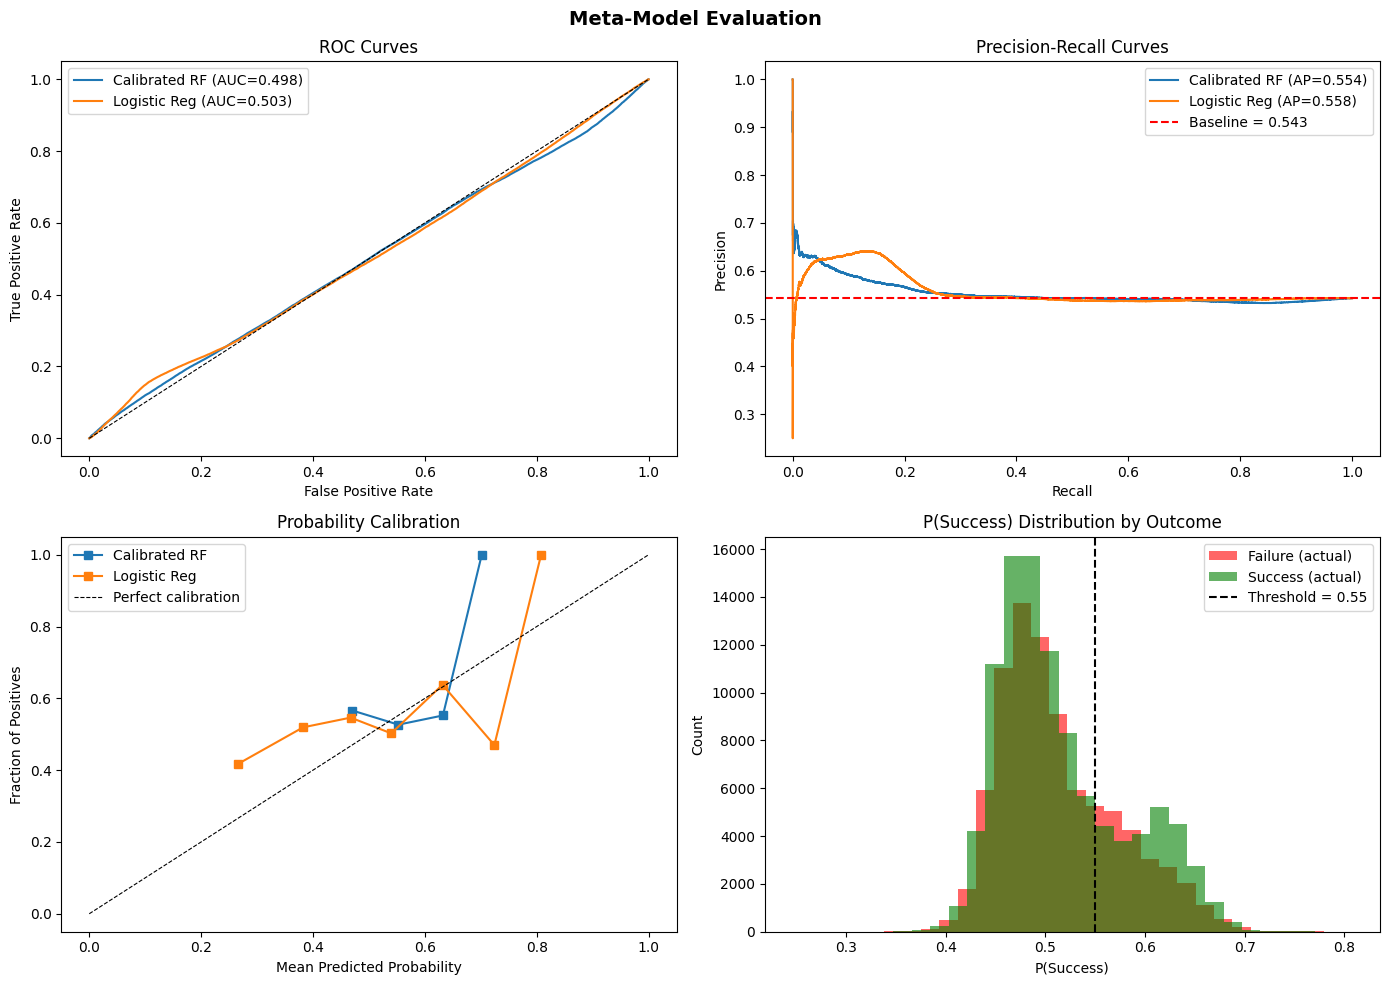

In [10]:
# ── Evaluation Plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ROC Curves
ax = axes[0, 0]
for name, proba, auc_val in [
    ('Calibrated RF', rf_proba, rf_auc),
    ('Logistic Reg',  lr_proba, lr_auc)
]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# 2. Precision-Recall Curves
ax = axes[0, 1]
for name, proba in [('Calibrated RF', rf_proba), ('Logistic Reg', lr_proba)]:
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
base_rate = y_te.mean()
ax.axhline(base_rate, color='red', linestyle='--', label=f'Baseline = {base_rate:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()

# 3. Calibration Curve
ax = axes[1, 0]
for name, proba in [('Calibrated RF', rf_proba), ('Logistic Reg', lr_proba)]:
    prob_true, prob_pred = calibration_curve(y_te, proba, n_bins=10)
    ax.plot(prob_pred, prob_true, 's-', label=name)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Probability Calibration')
ax.legend()

# 4. P(Success) Distribution
ax = axes[1, 1]
ax.hist(best_meta_proba[y_te == 0], bins=30, alpha=0.6, color='red',   label='Failure (actual)')
ax.hist(best_meta_proba[y_te == 1], bins=30, alpha=0.6, color='green', label='Success (actual)')
ax.axvline(PSUCCESS_THRESHOLD, color='black', linestyle='--',
           label=f'Threshold = {PSUCCESS_THRESHOLD}')
ax.set_xlabel('P(Success)')
ax.set_ylabel('Count')
ax.set_title('P(Success) Distribution by Outcome')
ax.legend()

plt.suptitle('Meta-Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(WD / 'meta_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Generate P(Success) for Full OOS Period

In [11]:
# Apply the meta-model to ALL available alpha signals (not just test set)
meta_all = meta_clean.copy()
X_all    = meta_all[META_FEATS].values.astype(np.float32)
X_all_s  = scaler.transform(X_all)

meta_all['p_success'] = best_meta.predict_proba(X_all_s)[:, 1]

# Quality check: P(Success) statistics
print('P(Success) statistics across full panel:')
print(meta_all['p_success'].describe())

# How many signals pass the threshold?
n_pass = (meta_all['p_success'] >= PSUCCESS_THRESHOLD).sum()
print(f'\nSignals passing threshold {PSUCCESS_THRESHOLD}: {n_pass:,} / {len(meta_all):,} = {n_pass/len(meta_all):.1%}')

P(Success) statistics across full panel:
count    606878.000000
mean          0.504799
std           0.056167
min           0.219594
25%           0.465724
50%           0.494594
75%           0.533449
max           0.820339
Name: p_success, dtype: float64

Signals passing threshold 0.55: 114,829 / 606,878 = 18.9%


In [13]:
# ── Impact of Meta-filtering on Alpha signal quality ─────────────────────────
# Compare IC of raw alpha vs. meta-filtered alpha

from scipy.stats import spearmanr

def ic_analysis_filtered(df, p_threshold, target_col='fwd_ret_5d', signal_col='pred_ensemble'):
    """Rank IC for signals above p_threshold vs all signals."""
    ic_all      = []
    ic_filtered = []

    for dt, group in df.groupby('date'):
        g = group.dropna(subset=[signal_col, target_col, 'p_success'])
        if len(g) < 10:
            continue
        r_all, _ = spearmanr(g[signal_col], g[target_col])
        ic_all.append(r_all)

        filtered = g[g['p_success'] >= p_threshold]
        if len(filtered) < 5:
            continue
        r_filt, _ = spearmanr(filtered[signal_col], filtered[target_col])
        ic_filtered.append(r_filt)

    return np.nanmean(ic_all), np.nanmean(ic_filtered)

# Merge p_success back onto OOS predictions for overlapping dates/tickers
meta_slim = meta_all[['date', 'ticker', 'p_success']]
oos_with_ps = oos_preds.merge(meta_slim, on=['date', 'ticker'], how='inner')

# Ensure target column exists with canonical name 'fwd_ret_5d'
if 'fwd_ret_5d' not in oos_with_ps.columns:
    oos_with_ps = oos_with_ps.merge(
        panel[['date', 'ticker', 'fwd_ret_5d']].drop_duplicates(),
        on=['date', 'ticker'],
        how='left'
    )

# Handle pandas suffixing when both merge sources contain fwd_ret_5d
if 'fwd_ret_5d' not in oos_with_ps.columns:
    fallback_cols = [c for c in ['fwd_ret_5d_x', 'fwd_ret_5d_y'] if c in oos_with_ps.columns]
    if fallback_cols:
        oos_with_ps['fwd_ret_5d'] = oos_with_ps[fallback_cols].bfill(axis=1).iloc[:, 0]

print('── IC: Raw Alpha vs Meta-Filtered Alpha ──')
for thr in [0.50, 0.55, 0.60, 0.65, 0.70]:
    ic_raw, ic_filt = ic_analysis_filtered(oos_with_ps, thr)
    coverage = (oos_with_ps['p_success'] >= thr).mean()
    lift = ic_filt / ic_raw if ic_raw != 0 else 0
    print(f'  threshold={thr:.2f}  IC_raw={ic_raw:.4f}  IC_filtered={ic_filt:.4f}  '
          f'Lift={lift:.2f}x  Coverage={coverage:.1%}')

── IC: Raw Alpha vs Meta-Filtered Alpha ──
  threshold=0.50  IC_raw=0.0151  IC_filtered=0.0220  Lift=1.46x  Coverage=45.7%
  threshold=0.55  IC_raw=0.0151  IC_filtered=0.0276  Lift=1.83x  Coverage=18.9%
  threshold=0.60  IC_raw=0.0151  IC_filtered=0.0280  Lift=1.86x  Coverage=7.8%
  threshold=0.65  IC_raw=0.0151  IC_filtered=-0.0060  Lift=-0.40x  Coverage=1.7%
  threshold=0.70  IC_raw=0.0151  IC_filtered=0.1363  Lift=9.04x  Coverage=0.1%


## 6 — Save Meta-Model & P(Success) Scores

In [14]:
# Save meta-model
with open(WD / 'meta_model.pkl', 'wb') as f:
    pickle.dump(best_meta, f)

# Save meta-model scaler
with open(WD / 'meta_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save P(Success) predictions
meta_all[['date', 'ticker', 'alpha_signal', 'p_success', 'tb_label', 'vol_sigma']].to_parquet(
    WD / 'p_success.parquet', index=False
)

# Save metadata
meta_model_meta = {
    'meta_model_type':   best_meta_name,
    'meta_features':     META_FEATS,
    'p_success_threshold': PSUCCESS_THRESHOLD,
    'test_auc':          float(roc_auc_score(y_te, best_meta_proba)),
    'test_brier':        float(brier_score_loss(y_te, best_meta_proba)),
    'upper_multiplier':  UPPER_MULTIPLIER,
    'lower_multiplier':  LOWER_MULTIPLIER,
    'vertical_barrier':  VERTICAL_BARRIER,
    'vol_window':        VOL_WINDOW,
}
with open(WD / 'meta_model_meta.json', 'w') as f:
    json.dump(meta_model_meta, f, indent=2)

print('✓ Saved:')
print('  meta_model.pkl')
print('  meta_scaler.pkl')
print('  p_success.parquet')
print('  meta_model_meta.json')

✓ Saved:
  meta_model.pkl
  meta_scaler.pkl
  p_success.parquet
  meta_model_meta.json
